# Exploratory Data Analysis — Telco Customer Churn

Practice 1 — Software Development Oriented to Machine Learning (UPNA).

This notebook explores the cleaned Telco Customer Churn dataset. All data
loading and cleaning logic lives in `telco_churn.dataset` — this notebook
only imports and calls it, it does not redefine it.

## 1. Loading the data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from telco_churn.config import FIGURES_DIR, RAW_DATA_DIR
from telco_churn.dataset import clean_data, load_raw_data

sns.set_theme(style="whitegrid")

df = load_raw_data(RAW_DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = clean_data(df)

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

2026-09-10 00:08:01.559 | INFO     | telco_churn.config:<module>:11 - PROJ_ROOT path is: /home/alumno/Desktop/telco_customer_churn_prediction


Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 2. Data quality check

`TotalCharges` is already fixed by `clean_data()` (11 blank rows, all with
`tenure == 0`, filled with 0). Checking for anything else:

In [4]:
print("Duplicated customerID:", df["customerID"].duplicated().sum())
print("Remaining missing values:", df.isnull().sum().sum())

Duplicated customerID: 0
Remaining missing values: 0


## 3. Target distribution (Churn)

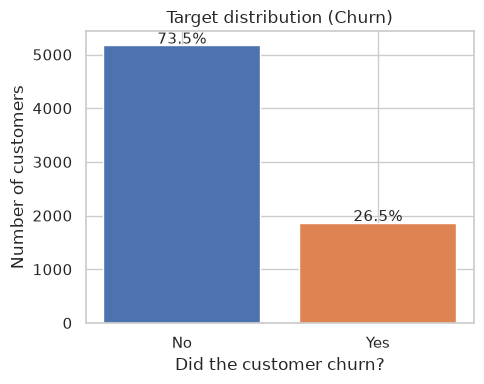

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

bars = ax.bar(churn_counts.index, churn_counts.values, color=["#4C72B0", "#DD8452"])
for bar, pct in zip(bars, churn_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", fontsize=11)

ax.set_title("Target distribution (Churn)")
ax.set_xlabel("Did the customer churn?")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

## 4. Numeric feature distributions

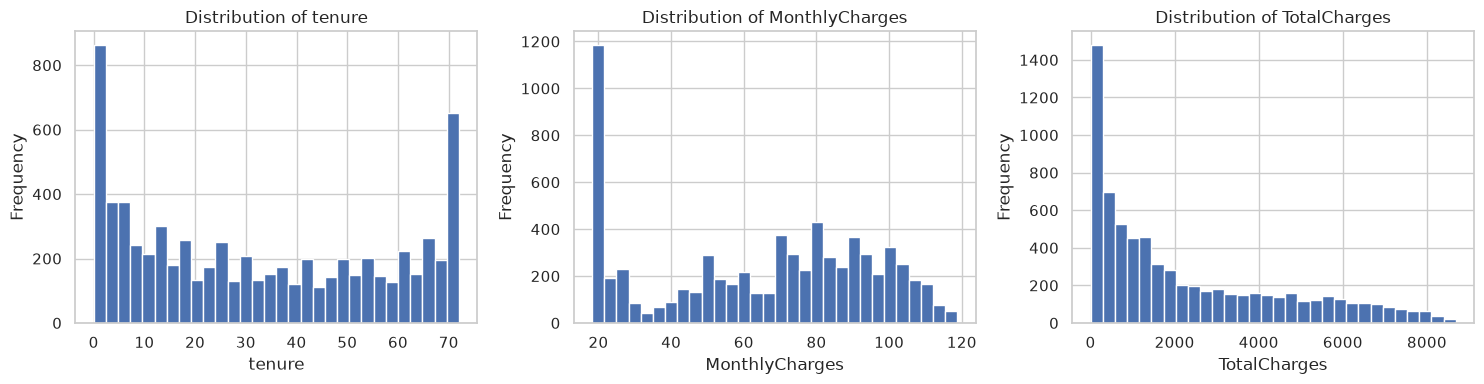

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=150)
plt.show()

## 5. Numeric features vs Churn

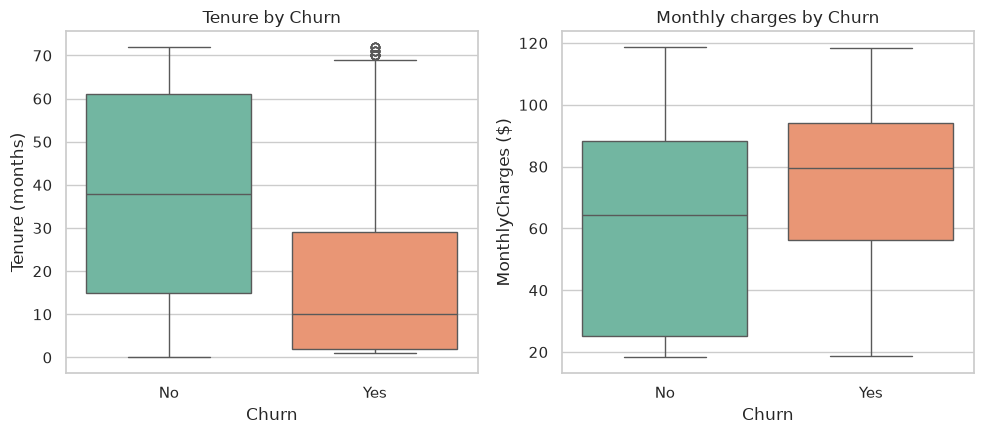

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], hue="Churn",
            palette="Set2", legend=False)
axes[0].set_title("Tenure by Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Tenure (months)")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], hue="Churn",
            palette="Set2", legend=False)
axes[1].set_title("Monthly charges by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("MonthlyCharges ($)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_vs_churn_boxplots.png", dpi=150)
plt.show()

## 6. Categorical features vs Churn

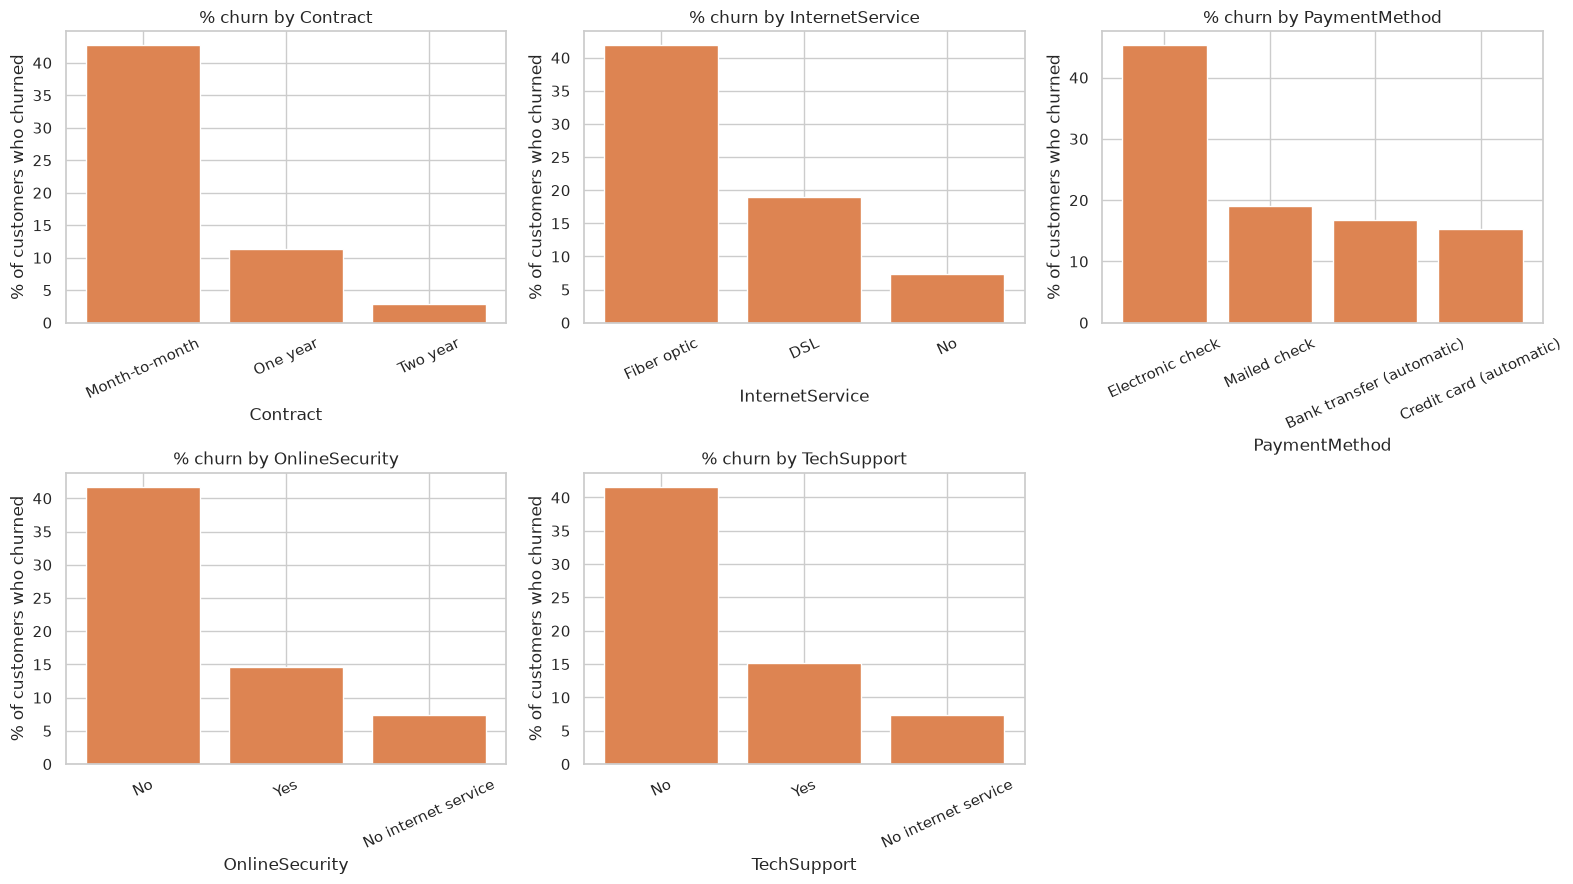

In [9]:
categorical_cols = ["Contract", "InternetService", "PaymentMethod",
                     "OnlineSecurity", "TechSupport"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    churn_rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
    churn_rate = churn_rate.sort_values(ascending=False)
    ax.bar(churn_rate.index, churn_rate.values, color="#DD8452")
    ax.set_title(f"% churn by {col}")
    ax.set_ylabel("% of customers who churned")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=25)

axes[-1].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_vs_churn.png", dpi=150)
plt.show()

## 7. Correlation heatmap

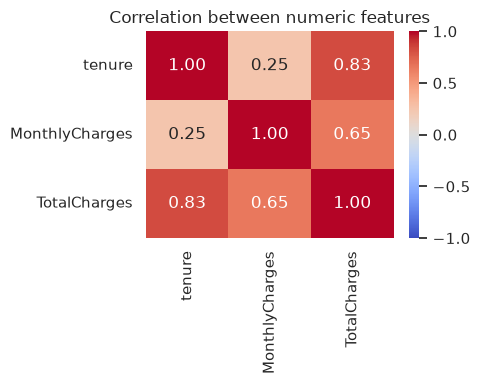

In [10]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges"]]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between numeric features")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

## 8. Conclusions

- **Class imbalance**: 26.5% of customers churned vs. 73.5% who didn't —
  moderate imbalance, worth keeping in mind for evaluation (plain accuracy
  can be misleading; this is why the assignment's bonus section on
  calibration curves matters).
- **Contract type is the strongest signal found**: month-to-month
  customers churn at 42.7%, vs. 11.3% for one-year and just 2.8% for
  two-year contracts.
- **Fiber optic internet customers churn more** (41.9%) than DSL (19.0%)
  or no-internet customers (7.4%) — possibly price or service quality
  related, worth checking against `MonthlyCharges`.
- **Lack of add-on services correlates with churn**: customers without
  `OnlineSecurity` or `TechSupport` churn at ~42%, vs. ~15% for those who
  have them.
- **Electronic check payers churn the most** (45.3%) compared to any
  automatic payment method (15-19%).
- **Tenure is the clearest numeric differentiator**: churners have stayed
  18.0 months on average vs. 37.6 months for non-churners.
- **`tenure` and `TotalCharges` are strongly correlated** (0.83, expected —
  longer customers accumulate more total billing), while `tenure` and
  `MonthlyCharges` are only weakly correlated (0.25). This is useful for
  the modeling step: `TotalCharges` carries limited extra information
  once `tenure` is known.